In [1]:
import warnings
import sys
import os
import time
import argparse
import nibabel as nib
from mpi4py import MPI
import numpy as np
import pandas as pd
from scipy import stats
from scipy.spatial.distance import squareform, pdist
from sklearn.preprocessing import StandardScaler
from brainiak.searchlight.searchlight import Searchlight
import matplotlib.pyplot as plt
from nilearn import image, plotting, datasets
from ants import image_read, image_write, apply_transforms
import nilearn
from nilearn.image import resample_to_img
from nilearn import plotting
from surfplot import Plot
from matplotlib.colors import ListedColormap
from os.path import join, exists
import ast
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from neuromaps.datasets import fetch_fslr
from matplotlib.colors import Normalize
import numpy as np
from pyvirtualdisplay import Display
import os
# Now your original code
import seaborn as sns
import matplotlib
import matplotlib.pyplot as plt
from surfplot import Plot
import vtk
from neuromaps import transforms
from neuromaps.datasets import fetch_annotation
vtk.vtkObject.GlobalWarningDisplayOff()
from neuromaps.datasets import fetch_fslr

# Surface plotting code

In [2]:
import nibabel as nib
from pyvirtualdisplay import Display
from neuromaps import transforms
from surfplot import Plot
from neuromaps.datasets import fetch_fslr

def create_surface_plot(glm_dir, contrast, output_filename='brain_plot.png', 
                       cmap='YlOrBr_r', dpi=300, display_size=(1024, 768)):
    """
    Create a surface plot of neuroimaging data transformed to fsLR space.
    
    Parameters:
    -----------
    glm_dir : str
        Directory containing GLM analysis results
    contrast : str
        Name of the contrast (e.g., 'visual-audio')
    output_filename : str, optional
        Name of the output file (default: 'brain_plot.png')
    cmap : str, optional
        Colormap for the plot (default: 'YlOrBr_r')
    dpi : int, optional
        Resolution for saved figure (default: 300)
    display_size : tuple, optional
        Size of virtual display (default: (1024, 768))
    
    Returns:
    --------
    fig : matplotlib.figure.Figure
        The generated figure object
    """
    
    # Start virtual display
    display = Display(visible=0, size=display_size)
    display.start()
    
    try:
        # Construct file path
        fn = f"{glm_dir}/{contrast}/MNI152NLin2009cAsym/randomise_output_{contrast}_MNI152NLin2009cAsym_tfce_corrp_tstat1.nii.gz"
        
        # Load and transform the data
        nii = nib.load(fn)
        
        # Transform results to fsLR space
        fslr = transforms.mni152_to_fslr(nii, '164k')
        fslr_lh, fslr_rh = fslr
        
        # Create the surface plot
        surfaces = fetch_fslr(density='164k')
        lh, rh = surfaces['inflated']
        
        p = Plot(surf_lh=lh, surf_rh=rh)
        p.add_layer({'left': fslr_lh, 'right': fslr_rh}, cmap=cmap)
        
        fig = p.build()
        fig.show()
        
        if output_filename:
            fig.savefig(output_filename, dpi=dpi, bbox_inches='tight')
        
        return fig
        
    finally:
        # Always stop virtual display, even if an error occurs
        display.stop()

In [3]:
import re
import numpy as np, pandas as pd, nibabel as nib
from nilearn import datasets, image
from nilearn.image import resample_to_img
from nilearn.reporting import get_clusters_table
from scipy.spatial import cKDTree

# ---------------- settings ----------------
GLM_BASE    = "/gpfs/milgram/scratch60/turk-browne/or62/sandbox/searchlight_rsa_results"  # RSA searchlight
GLM_DIR     = "/gpfs/milgram/scratch60/turk-browne/or62/sandbox/GLM_structs"              # GLM whole-brain
EXCLUDE_SUB = ("White Matter", "Cerebral Cortex", "Ventric", "Background")

# ---------------- file-path builders ----------------
def path_contrasts(name, kind):   # RSA: contrasts/<name>/...
    return (f"{GLM_BASE}/contrasts/{name}/"
            f"randomise_output_contrasts_{name}_MNI152NLin2009cAsym_{kind}.nii.gz")

def path_condition(name, kind):   # RSA: <name>/MNI152NLin2009cAsym/...
    return (f"{GLM_BASE}/{name}/MNI152NLin2009cAsym/"
            f"randomise_output_condition_{name}_MNI152NLin2009cAsym_{kind}.nii.gz")

def path_glm(name, kind):         # GLM whole-brain (smoothed maps)
    return (f"{GLM_DIR}/{name}/MNI152NLin2009cAsym/"
            f"randomise_output_{name}_MNI152NLin2009cAsym_{kind}.nii.gz")

# ---------------- Harvard-Oxford labeling resources (build once) ----------------
def strip_side(name):
    for s in ("Left ", "Right "):
        if name.startswith(s):
            return name[len(s):]
    return name

def build_resources(ref):
    aff = ref.affine
    ho_c = datasets.fetch_atlas_harvard_oxford('cort-maxprob-thr25-2mm')
    ho_s = datasets.fetch_atlas_harvard_oxford('sub-maxprob-thr25-2mm')
    ho_c_rs = resample_to_img(image.load_img(ho_c.maps), ref, interpolation='nearest').get_fdata().astype(int)
    ho_s_rs = resample_to_img(image.load_img(ho_s.maps), ref, interpolation='nearest').get_fdata().astype(int)
    c_lab = np.array([str(s) for s in ho_c.labels])
    s_lab = np.array([str(s) for s in ho_s.labels])

    region_vol = np.empty(ho_c_rs.shape, dtype=object); region_vol[:] = ""
    cort = ho_c_rs > 0
    region_vol[cort] = c_lab[ho_c_rs[cort]]
    s_names = np.array([strip_side(n) for n in s_lab])
    s_bad   = np.array([any(e in n for e in EXCLUDE_SUB) for n in s_lab])
    sub = (~cort) & (ho_s_rs > 0) & (~s_bad[ho_s_rs])
    region_vol[sub] = s_names[ho_s_rs[sub]]

    ijk = np.argwhere(region_vol != "")
    mm  = nib.affines.apply_affine(aff, ijk)
    return dict(affine=aff, region_vol=region_vol, kdt=cKDTree(mm),
                labeled_names=region_vol[ijk[:, 0], ijk[:, 1], ijk[:, 2]])

# ---------------- helpers ----------------
def clean_region(name):
    name = re.sub(r"\s*\(includes[^)]*\)", "", name)
    if "," in name:
        head, tail = name.split(",", 1)
        tail = re.sub(r"\s*division\s*$", "", tail.strip())
        name = f"{head.strip()} ({tail})"
    name = name.lower()
    return name[:1].upper() + name[1:]

def label_coord(x, y, z, res, tol_mm=6.0):
    i, j, k = np.round(np.linalg.inv(res["affine"]) @ [x, y, z, 1])[:3].astype(int)
    rv = res["region_vol"]
    inside = (0 <= i < rv.shape[0]) and (0 <= j < rv.shape[1]) and (0 <= k < rv.shape[2])
    reg = rv[i, j, k] if inside else ""
    if reg == "":
        d, idx = res["kdt"].query([x, y, z])
        reg = res["labeled_names"][idx] if d <= tol_mm else "Unlabeled"
    return reg

# ---------------- core: one cluster DataFrame (no file writing) ----------------
def clusters_only(t_map, corrp_list, p_level, res, min_voxels=20, min_distance=8, subpeaks=True):
    tdata = t_map.get_fdata()
    sig = np.logical_and.reduce([c.get_fdata() > (1 - p_level) for c in corrp_list])
    masked = np.where(sig & np.isfinite(tdata), tdata, 0.0).astype(np.float32)
    tab = get_clusters_table(nib.Nifti1Image(masked, t_map.affine), stat_threshold=1e-6,
                             cluster_threshold=min_voxels, min_distance=min_distance)
    cols = ["Cluster", "Region", "Hemi", "X", "Y", "Z", "Peak t", "Size (mm3)"]
    if len(tab) == 0:
        return pd.DataFrame(columns=cols)
    tab["Region"] = [clean_region(label_coord(r.X, r.Y, r.Z, res)) for r in tab.itertuples()]
    tab["Hemi"]   = np.where(tab["X"] < 0, "L", "R")
    tab = tab.rename(columns={"Cluster ID": "Cluster", "Peak Stat": "Peak t",
                              "Cluster Size (mm3)": "Size (mm3)"})
    for c in ("X", "Y", "Z"):
        tab[c] = tab[c].round().astype(int)
    tab["Peak t"] = tab["Peak t"].round(2)
    tab = tab[cols]
    if not subpeaks:   # keep only each cluster's main peak (rows that carry a Size value)
        tab = tab[tab["Size (mm3)"].apply(lambda s: s != "" and not pd.isna(s))].reset_index(drop=True)
    return tab

# ---------------- one table, one or more comparisons stacked, single threshold ----------------
def supertable(blocks, p_level, title, label, out_tex, short=None, extra="", min_voxels=20):
    esc = lambda s: str(s).replace("&", r"\&").replace("%", r"\%").replace("_", r"\_")
    short = short or title.rstrip(".")
    extra = (extra + " ") if extra else ""
    header = (r"\textbf{Cluster} & \textbf{Region} & \textbf{Hem.} & "
              r"\multicolumn{3}{c}{\footnotesize MNI $(x,y,z)$} & "
              r"\textbf{Peak $t$} & \textbf{Size (mm$^3$)} \\")
    caption = (rf"\caption[{short}]{{\textbf{{{title}}} "
               rf"Significant clusters, corrected using threshold-free cluster enhancement (TFCE) at $P < {p_level:g}$. "
               rf"{extra}"
               rf"For each cluster, the peak and local maxima ($\geq 8$~mm apart; a, b, \ldots) are listed. "
               rf"Cluster = cluster index; Region = Harvard-Oxford atlas label at the coordinate; Hem.\ = hemisphere; "
               rf"$x, y, z$ = peak MNI coordinates (mm); Peak $t$ = peak $t$-statistic; Size = cluster extent (mm$^3$). "
               rf"Clusters smaller than {min_voxels} voxels are omitted.}}\label{{{label}}}")
    L = [r"\setlength{\LTleft}{\fill}",
         r"\setlength{\LTright}{\fill}",
         r"\setlength{\LTcapwidth}{\textwidth}",
         r"\begin{longtable}{@{\extracolsep{11.3pt}}>{\footnotesize}l>{\footnotesize}l>{\footnotesize}c "
         r">{\footnotesize}r@{\extracolsep{0pt},\,}>{\footnotesize}r@{,\,}>{\footnotesize}r "
         r"@{\extracolsep{11.3pt}}>{\footnotesize}c >{\footnotesize}r@{}}",
         r"\toprule", header, r"\midrule", r"\endfirsthead",
         r"\multicolumn{8}{c}{\footnotesize\tablename~\thetable\ (continued)} \\",
         r"\toprule", header, r"\midrule", r"\endhead",
         r"\midrule", r"\multicolumn{8}{r}{\footnotesize\textit{Continued on next page}} \\", r"\endfoot",
         r"\bottomrule", r"\noalign{\vskip0.6em}", caption + r"\\", r"\endlastfoot"]
    for i, (block_title, tab) in enumerate(blocks):
        L.append(rf"\multicolumn{{8}}{{c}}{{\footnotesize\textit{{{block_title}}}}} \\")
        L.append(r"\midrule")
        if len(tab) == 0:
            L.append(r"\multicolumn{8}{c}{\footnotesize\textit{no significant clusters}} \\")
        for _, r in tab.iterrows():
            s = r["Size (mm3)"]; size = "" if (s == "" or pd.isna(s)) else f"{int(s)}"
            L.append(f'{r["Cluster"]} & {esc(r["Region"])} & {r["Hemi"]} & '
                     f'${int(r["X"])}$ & ${int(r["Y"])}$ & ${int(r["Z"])}$ & {r["Peak t"]:.2f} & {size} \\\\')
        if i < len(blocks) - 1:
            L.append(r"\midrule")
    L += [r"\end{longtable}"]
    with open(out_tex, "w") as f:
        f.write("\n".join(L) + "\n")

# GLM Whole-Brain Plotting

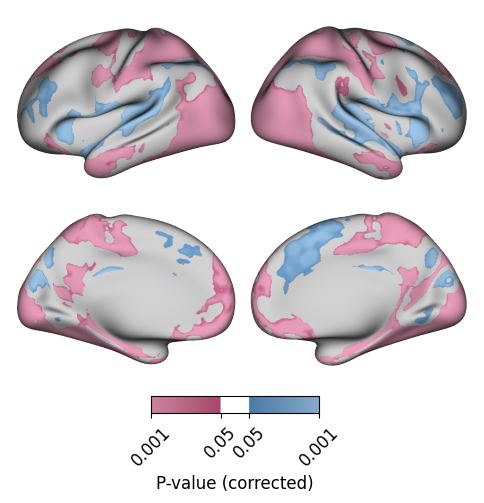

In [4]:
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import numpy as np

# Start virtual display
display = Display(visible=0, size=(1024, 768))
display.start()

# Load MNI-158 results
glm_dir = "/gpfs/milgram/scratch60/turk-browne/or62/sandbox/GLM_structs"

# Two-tailed design (smoothed maps): one folder, both tails from the two-contrast
# randomise run. tstat1 = audio > visual (positive), tstat2 = visual > audio (negative).
contrast = "audio-visual"
fn_pos = f"{glm_dir}/{contrast}/MNI152NLin2009cAsym/randomise_output_{contrast}_MNI152NLin2009cAsym_tfce_corrp_tstat1.nii.gz"
fn_neg = f"{glm_dir}/{contrast}/MNI152NLin2009cAsym/randomise_output_{contrast}_MNI152NLin2009cAsym_tfce_corrp_tstat2.nii.gz"

nii_pos = nib.load(fn_pos)
nii_neg = nib.load(fn_neg)

# Convert from (1-p) to p for both
nii_pos_p = image.math_img('1 - X', X=nii_pos)
nii_neg_p = image.math_img('1 - X', X=nii_neg)

# Define p-value thresholds
p_threshold = 0.05  # minimum p-value to show
p_max = 0.001       # maximum p-value (most significant)

# Transform results to fslr space FIRST
fslr_pos = transforms.mni152_to_fslr(nii_pos_p, '164k')
fslr_neg = transforms.mni152_to_fslr(nii_neg_p, '164k')

# Extract data arrays
fslr_lh_pos = fslr_pos[0].darrays[0].data.copy()
fslr_rh_pos = fslr_pos[1].darrays[0].data.copy()
fslr_lh_neg = fslr_neg[0].darrays[0].data.copy()
fslr_rh_neg = fslr_neg[1].darrays[0].data.copy()

# Threshold and create signed data
# Positive (audio > visual): keep where p < 0.05, cap at p_max
fslr_lh_pos[fslr_lh_pos > p_threshold] = np.nan
fslr_rh_pos[fslr_rh_pos > p_threshold] = np.nan
fslr_lh_pos[fslr_lh_pos < p_max] = p_max
fslr_rh_pos[fslr_rh_pos < p_max] = p_max

# Negative (visual > audio): keep where p < 0.05, cap at p_max
fslr_lh_neg[fslr_lh_neg > p_threshold] = np.nan
fslr_rh_neg[fslr_rh_neg > p_threshold] = np.nan
fslr_lh_neg[fslr_lh_neg < p_max] = p_max
fslr_rh_neg[fslr_rh_neg < p_max] = p_max

# Add medial wall masking
surfaces = fetch_fslr(density='164k')
medial_mask_lh = nib.load(surfaces['medial'][0]).agg_data()
medial_mask_rh = nib.load(surfaces['medial'][1]).agg_data()
fslr_lh_pos[medial_mask_lh == 0] = np.nan
fslr_rh_pos[medial_mask_rh == 0] = np.nan
fslr_lh_neg[medial_mask_lh == 0] = np.nan
fslr_rh_neg[medial_mask_rh == 0] = np.nan

# Transform to log space (with correct sign)
fslr_lh_pos_log = -np.log10(fslr_lh_pos)
fslr_rh_pos_log = -np.log10(fslr_rh_pos)
fslr_lh_neg_log = np.log10(fslr_lh_neg)
fslr_rh_neg_log = np.log10(fslr_rh_neg)

# Combine
fslr_lh_data = np.where(~np.isnan(fslr_lh_pos_log), fslr_lh_pos_log, fslr_lh_neg_log)
fslr_rh_data = np.where(~np.isnan(fslr_rh_pos_log), fslr_rh_pos_log, fslr_rh_neg_log)

# Log thresholds
log_max = -np.log10(p_max)              # ~3   -> p = 0.001
log_threshold = -np.log10(p_threshold)  # ~1.30 -> p = 0.05

# Set values within threshold range to NaN
fslr_lh_data[(fslr_lh_data > -log_threshold) & (fslr_lh_data < log_threshold)] = np.nan
fslr_rh_data[(fslr_rh_data > -log_threshold) & (fslr_rh_data < log_threshold)] = np.nan

# --- Brain colormap (unchanged): dark at 0.05, bright at 0.001 ---
pos_neg_threshold = (log_max - log_threshold) / (2 * log_max)
pos_pos_threshold = (log_max + log_threshold) / (2 * log_max)

dark_rose   = (0.65, 0.28, 0.42)   # at 0.05
bright_rose = (0.80, 0.52, 0.62)   # at 0.001
dark_blue   = (0.29, 0.48, 0.65)   # at 0.05
bright_blue = (0.52, 0.67, 0.80)   # at 0.001

cdict = {
    'red':   [(0.0, bright_rose[0], bright_rose[0]),
              (pos_neg_threshold, dark_rose[0], 1.0),
              (pos_pos_threshold, 1.0, dark_blue[0]),
              (1.0, bright_blue[0], bright_blue[0])],
    'green': [(0.0, bright_rose[1], bright_rose[1]),
              (pos_neg_threshold, dark_rose[1], 1.0),
              (pos_pos_threshold, 1.0, dark_blue[1]),
              (1.0, bright_blue[1], bright_blue[1])],
    'blue':  [(0.0, bright_rose[2], bright_rose[2]),
              (pos_neg_threshold, dark_rose[2], 1.0),
              (pos_pos_threshold, 1.0, dark_blue[2]),
              (1.0, bright_blue[2], bright_blue[2])]
}
cmap_custom = LinearSegmentedColormap('custom_diverging', cdict)

# Plot brain WITHOUT surfplot's automatic colorbar
lh, rh = surfaces['inflated']
p = Plot(surf_lh=lh, surf_rh=rh, brightness=0.6)
p.add_layer({'left': fslr_lh_data, 'right': fslr_rh_data},
            cmap=cmap_custom,
            color_range=(-log_max, log_max),
            cbar=False)
fig = p.build()

# --- Custom compact colorbar: dark = 0.05, light = 0.001, small white divider ---
ncol = 512
gap = 0.17               # white-divider width as fraction of bar (tweak to taste)
seg = (1.0 - gap) / 2.0
L = int(seg * ncol); G = int(gap * ncol); R = ncol - L - G

def _grad(c0, c1, n):    # c0 at left edge, c1 at right edge
    return np.stack([np.linspace(c0[k], c1[k], n) for k in range(3)], axis=1)

bar = np.ones((1, ncol, 3))
bar[0, :L]    = _grad(bright_rose, dark_rose, L)   # 0.001 -> 0.05 (rose)
bar[0, L:L+G] = 1.0                                # white divider
bar[0, L+G:]  = _grad(dark_blue, bright_blue, R)   # 0.05 -> 0.001 (blue)

cax = fig.add_axes([0.36, 0.06, 0.28, 0.035])      # [left, bottom, w, h] - tweak to taste
cax.imshow(bar, aspect='auto', extent=[0, 1, 0, 1])
cax.set_yticks([])
cax.set_xticks([0, seg, seg + gap, 1.0])
cax.set_xticklabels(['0.001', '0.05', '0.05', '0.001'], rotation=45, ha='center', fontsize=12)
cax.set_xlabel('P-value (corrected)', fontsize=12)

fig.savefig('glm_unisensory.svg', bbox_inches='tight')

# Stop virtual display when done
display.stop()

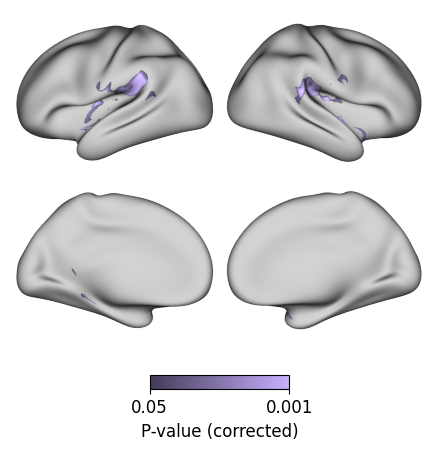

In [5]:
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import numpy as np
import nibabel as nib
from nilearn import image
from neuromaps import transforms
from surfplot import Plot
from pyvirtualdisplay import Display
# Start virtual display
display = Display(visible=0, size=(1024, 768))
display.start()
# Load MNI-158 results
glm_dir = "/gpfs/milgram/scratch60/turk-browne/or62/sandbox/GLM_structs"
# Load both contrasts needed for conjunction
contrast_cong_audio = "congruent-audio"
contrast_cong_visual = "congruent-visual"
# Load positive results (stored as 1-p in FSL) for both contrasts
fn_cong_audio = f"{glm_dir}/{contrast_cong_audio}/MNI152NLin2009cAsym/randomise_output_{contrast_cong_audio}_MNI152NLin2009cAsym_tfce_corrp_tstat1.nii.gz"
fn_cong_visual = f"{glm_dir}/{contrast_cong_visual}/MNI152NLin2009cAsym/randomise_output_{contrast_cong_visual}_MNI152NLin2009cAsym_tfce_corrp_tstat1.nii.gz"
nii_cong_audio = nib.load(fn_cong_audio)
nii_cong_visual = nib.load(fn_cong_visual)
# Convert from (1-p) to p for both
nii_cong_audio_p = image.math_img('1 - X', X=nii_cong_audio)
nii_cong_visual_p = image.math_img('1 - X', X=nii_cong_visual)
# Conjunction: take the MAXIMUM p-value at each voxel (most conservative)
# This implements the "minimum statistic" conjunction (Nichols et al., 2005)
nii_conjunction_p = image.math_img('np.maximum(img1, img2)', 
                                    img1=nii_cong_audio_p, 
                                    img2=nii_cong_visual_p)
# Define p-value thresholds
p_threshold = 0.05  # minimum p-value to show
p_max = 0.001       # maximum p-value (most significant)
# Transform results to fslr space 
fslr_conj = transforms.mni152_to_fslr(nii_conjunction_p, '164k')
# Extract data arrays
fslr_lh_conj = fslr_conj[0].darrays[0].data.copy()
fslr_rh_conj = fslr_conj[1].darrays[0].data.copy()
# Threshold and cap data
# Keep where p < 0.05, cap at p_max
fslr_lh_conj[fslr_lh_conj > p_threshold] = np.nan
fslr_rh_conj[fslr_rh_conj > p_threshold] = np.nan
fslr_lh_conj[fslr_lh_conj < p_max] = p_max
fslr_rh_conj[fslr_rh_conj < p_max] = p_max
# Fetch surfaces and medial wall mask
surfaces = fetch_fslr(density='164k')
medial_mask_lh = nib.load(surfaces['medial'][0]).agg_data()
medial_mask_rh = nib.load(surfaces['medial'][1]).agg_data()
fslr_lh_conj[medial_mask_lh == 0] = np.nan
fslr_rh_conj[medial_mask_rh == 0] = np.nan
# Transform to log space
fslr_lh_data = -np.log10(fslr_lh_conj)
fslr_rh_data = -np.log10(fslr_rh_conj)
# Calculate log thresholds
log_max = -np.log10(p_max)  # ~3
log_threshold = -np.log10(p_threshold)  # ~1.3

# #6f638f = (0.435, 0.388, 0.561) exact
# Scale: darker version at threshold, brighter at most sig (keeping exact ratios)
# Ratios: R:G:B = 0.78:0.69:1.0
dark_purple  = (0.26, 0.23, 0.34)   # ~60% of #6f638f — at threshold
light_purple = (0.78, 0.69, 1.0)    # Scaled to blue=1.0 — at most significant

cdict = {
    'red':   [(0.0, dark_purple[0], dark_purple[0]),
              (1.0, light_purple[0], light_purple[0])],
    'green': [(0.0, dark_purple[1], dark_purple[1]),
              (1.0, light_purple[1], light_purple[1])],
    'blue':  [(0.0, dark_purple[2], dark_purple[2]),
              (1.0, light_purple[2], light_purple[2])]
}
cmap_custom = LinearSegmentedColormap('sequential_purple', cdict)
# Colorbar settings
kws = {'location': 'bottom',
       'label_direction': 0,
       'fontsize': 12, 
       'aspect': 10,
       'draw_border': True}
# Plotting with LIGHTER BRAIN SURFACE
lh, rh = surfaces['inflated']
p = Plot(surf_lh=lh, surf_rh=rh, brightness=0.6)
p.add_layer({'left': fslr_lh_data, 'right': fslr_rh_data}, 
            cmap=cmap_custom, 
            color_range=(log_threshold, log_max))
fig = p.build(cbar_kws=kws)
# Add label and set ticks
for ax in fig.axes:
    if hasattr(ax, 'get_xlabel'):
        ax.set_xlabel('P-value (corrected)', fontsize=12)
        ax.set_xticks([log_threshold, log_max])
        ax.set_xticklabels(['0.05', '0.001'])
fig.savefig('glm_congruent_conjunction_audio_and_visual.svg', bbox_inches='tight')
# Stop virtual display when done
display.stop()

findfont: Font family ['Helvetica'] not found. Falling back to DejaVu Sans.


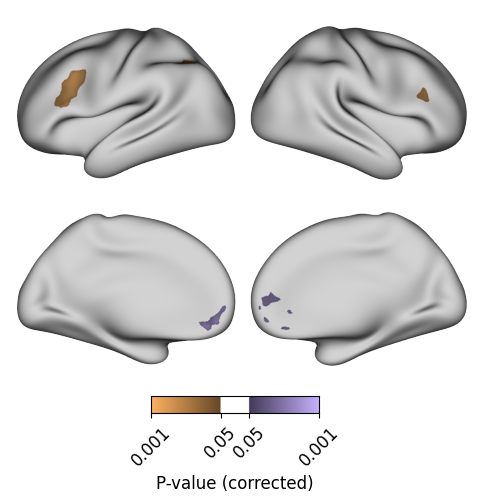

In [6]:
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import numpy as np
import nibabel as nib
from nilearn import image
from neuromaps import transforms
from neuromaps.datasets import fetch_fslr
from surfplot import Plot
from pyvirtualdisplay import Display

# Set font to Helvetica globally
plt.rcParams['font.family'] = 'Helvetica'

# Start virtual display
display = Display(visible=0, size=(1024, 768))
display.start()

# Load MNI-158 results
glm_dir = "/gpfs/milgram/scratch60/turk-browne/or62/sandbox/GLM_structs"

# RSA-style: each direction is its own one-sample (positive) randomise run.
contrast_pos = "congruent-incongruent"   # tstat1 = congruent > incongruent
contrast_neg = "incongruent-congruent"   # tstat1 = incongruent > congruent

fn_pos = f"{glm_dir}/{contrast_pos}/MNI152NLin2009cAsym/randomise_output_{contrast_pos}_MNI152NLin2009cAsym_tfce_corrp_tstat1.nii.gz"
fn_neg = f"{glm_dir}/{contrast_neg}/MNI152NLin2009cAsym/randomise_output_{contrast_neg}_MNI152NLin2009cAsym_tfce_corrp_tstat1.nii.gz"

nii_pos = nib.load(fn_pos)
nii_neg = nib.load(fn_neg)

# Convert from (1-p) to p for both
nii_pos_p = image.math_img('1 - X', X=nii_pos)
nii_neg_p = image.math_img('1 - X', X=nii_neg)

# Define p-value thresholds
p_threshold = 0.05  # minimum p-value to show
p_max = 0.001       # maximum p-value (most significant)

# Transform results to fslr space FIRST
fslr_pos = transforms.mni152_to_fslr(nii_pos_p, '164k')
fslr_neg = transforms.mni152_to_fslr(nii_neg_p, '164k')

# Extract data arrays
fslr_lh_pos = fslr_pos[0].darrays[0].data.copy()
fslr_rh_pos = fslr_pos[1].darrays[0].data.copy()
fslr_lh_neg = fslr_neg[0].darrays[0].data.copy()
fslr_rh_neg = fslr_neg[1].darrays[0].data.copy()

# Threshold: keep where p < 0.05, cap at p_max
fslr_lh_pos[fslr_lh_pos > p_threshold] = np.nan
fslr_rh_pos[fslr_rh_pos > p_threshold] = np.nan
fslr_lh_pos[fslr_lh_pos < p_max] = p_max
fslr_rh_pos[fslr_rh_pos < p_max] = p_max

fslr_lh_neg[fslr_lh_neg > p_threshold] = np.nan
fslr_rh_neg[fslr_rh_neg > p_threshold] = np.nan
fslr_lh_neg[fslr_lh_neg < p_max] = p_max
fslr_rh_neg[fslr_rh_neg < p_max] = p_max

# Add medial wall masking
surfaces = fetch_fslr(density='164k')
medial_mask_lh = nib.load(surfaces['medial'][0]).agg_data()
medial_mask_rh = nib.load(surfaces['medial'][1]).agg_data()
fslr_lh_pos[medial_mask_lh == 0] = np.nan
fslr_rh_pos[medial_mask_rh == 0] = np.nan
fslr_lh_neg[medial_mask_lh == 0] = np.nan
fslr_rh_neg[medial_mask_rh == 0] = np.nan

# Transform to log space
# Positive (congruent > incongruent) -> positive values -> purple side
# Negative (incongruent > congruent) -> negative values -> orange side
fslr_lh_pos_log = -np.log10(fslr_lh_pos)
fslr_rh_pos_log = -np.log10(fslr_rh_pos)
fslr_lh_neg_log = np.log10(fslr_lh_neg)
fslr_rh_neg_log = np.log10(fslr_rh_neg)

# Combine
fslr_lh_data = np.where(~np.isnan(fslr_lh_pos_log), fslr_lh_pos_log, fslr_lh_neg_log)
fslr_rh_data = np.where(~np.isnan(fslr_rh_pos_log), fslr_rh_pos_log, fslr_rh_neg_log)

# Log thresholds
log_max = -np.log10(p_max)              # ~3   -> p = 0.001
log_threshold = -np.log10(p_threshold)  # ~1.30 -> p = 0.05

# Set values within threshold range to NaN
fslr_lh_data[(fslr_lh_data > -log_threshold) & (fslr_lh_data < log_threshold)] = np.nan
fslr_rh_data[(fslr_rh_data > -log_threshold) & (fslr_rh_data < log_threshold)] = np.nan

# --- Brain colormap: dark at 0.05 (break at true threshold), light at 0.001 ---
pos_neg_threshold = (log_max - log_threshold) / (2 * log_max)
pos_pos_threshold = (log_max + log_threshold) / (2 * log_max)

# PURPLE: congruent > incongruent (positive side)
dark_purple  = (0.26, 0.23, 0.34)   # at 0.05
light_purple = (0.78, 0.69, 1.0)    # at 0.001
# ORANGE: incongruent > congruent (negative side)
dark_orange  = (0.40, 0.28, 0.15)   # at 0.05
light_orange = (1.0, 0.70, 0.38)    # at 0.001

cdict = {
    'red':   [(0.0, light_orange[0], light_orange[0]),
              (pos_neg_threshold, dark_orange[0], 1.0),
              (pos_pos_threshold, 1.0, dark_purple[0]),
              (1.0, light_purple[0], light_purple[0])],
    'green': [(0.0, light_orange[1], light_orange[1]),
              (pos_neg_threshold, dark_orange[1], 1.0),
              (pos_pos_threshold, 1.0, dark_purple[1]),
              (1.0, light_purple[1], light_purple[1])],
    'blue':  [(0.0, light_orange[2], light_orange[2]),
              (pos_neg_threshold, dark_orange[2], 1.0),
              (pos_pos_threshold, 1.0, dark_purple[2]),
              (1.0, light_purple[2], light_purple[2])]
}
cmap_custom = LinearSegmentedColormap('custom_diverging', cdict)

# Plot brain WITHOUT surfplot's automatic colorbar
lh, rh = surfaces['inflated']
p = Plot(surf_lh=lh, surf_rh=rh, brightness=0.6)
p.add_layer({'left': fslr_lh_data, 'right': fslr_rh_data},
            cmap=cmap_custom,
            color_range=(-log_max, log_max),
            cbar=False)
fig = p.build()

# --- Custom compact colorbar: dark = 0.05, light = 0.001, white divider ---
ncol = 512
gap = 0.17               # white-divider width (matches your original)
seg = (1.0 - gap) / 2.0
L = int(seg * ncol); G = int(gap * ncol); R = ncol - L - G

def _grad(c0, c1, n):    # c0 at left edge, c1 at right edge
    return np.stack([np.linspace(c0[k], c1[k], n) for k in range(3)], axis=1)

bar = np.ones((1, ncol, 3))
bar[0, :L]    = _grad(light_orange, dark_orange, L)    # 0.001 -> 0.05 (orange)
bar[0, L:L+G] = 1.0                                    # white divider
bar[0, L+G:]  = _grad(dark_purple, light_purple, R)    # 0.05 -> 0.001 (purple)

cax = fig.add_axes([0.36, 0.06, 0.28, 0.035])          # [left, bottom, w, h] - tweak
cax.imshow(bar, aspect='auto', extent=[0, 1, 0, 1])
cax.set_yticks([])
cax.set_xticks([0, seg, seg + gap, 1.0])
cax.set_xticklabels(['0.001', '0.05', '0.05', '0.001'], rotation=45, ha='center', fontsize=12)
cax.set_xlabel('P-value (corrected)', fontsize=12)

fig.savefig('glm_congruent_incongruent.svg', bbox_inches='tight')

# Stop virtual display when done
display.stop()

In [8]:
res_glm = build_resources(nib.load(path_glm("audio-visual", "tfce_corrp_tstat1")))
ld = nib.load
p = 0.05

glm_conj = image.math_img("np.minimum(a,b)",
                          a=ld(path_glm("congruent-audio","tstat1")),
                          b=ld(path_glm("congruent-visual","tstat1")))

glm_blocks = [
    (r"Auditory $>$ visual",
     clusters_only(ld(path_glm("audio-visual","tstat1")),
                   [ld(path_glm("audio-visual","tfce_corrp_tstat1"))], p, res_glm)),
    (r"Visual $>$ auditory",
     clusters_only(ld(path_glm("audio-visual","tstat2")),
                   [ld(path_glm("audio-visual","tfce_corrp_tstat2"))], p, res_glm)),
    (r"Multisensory facilitation (congruent $>$ auditory $\cap$ congruent $>$ visual)",
     clusters_only(glm_conj,
                   [ld(path_glm("congruent-audio","tfce_corrp_tstat1")),
                    ld(path_glm("congruent-visual","tfce_corrp_tstat1"))], p, res_glm)),
    (r"Congruent $>$ incongruent",
     clusters_only(ld(path_glm("congruent-incongruent","tstat1")),
                   [ld(path_glm("congruent-incongruent","tfce_corrp_tstat1"))], p, res_glm)),
    (r"Incongruent $>$ congruent",
     clusters_only(ld(path_glm("incongruent-congruent","tstat1")),
                   [ld(path_glm("incongruent-congruent","tfce_corrp_tstat1"))], p, res_glm)),
]

supertable(glm_blocks, p,
           "Whole-brain univariate (GLM) cluster peaks.",
           "table:glm-clusters-p05", "glm_clusters_p05.tex",
           short="Whole-brain univariate cluster peaks",
           extra=r"Bidirectional contrasts (auditory vs.\ visual; congruent vs.\ incongruent) are reported in both "
                 r"directions. Superior temporal sulcus (STS) effects appear under adjacent superior/middle temporal "
                 r"gyrus and planum temporale labels, as the Harvard-Oxford atlas does not delineate the sulcus.")

In [9]:
res_glm = build_resources(nib.load(path_glm("audio-visual", "tfce_corrp_tstat1")))
ld = nib.load
p = 0.001

glm_conj = image.math_img("np.minimum(a,b)",
                          a=ld(path_glm("congruent-audio","tstat1")),
                          b=ld(path_glm("congruent-visual","tstat1")))

glm_blocks = [
    (r"Auditory $>$ visual",
     clusters_only(ld(path_glm("audio-visual","tstat1")),
                   [ld(path_glm("audio-visual","tfce_corrp_tstat1"))], p, res_glm)),
    (r"Visual $>$ auditory",
     clusters_only(ld(path_glm("audio-visual","tstat2")),
                   [ld(path_glm("audio-visual","tfce_corrp_tstat2"))], p, res_glm)),
    (r"Multisensory facilitation (congruent $>$ auditory $\cap$ congruent $>$ visual)",
     clusters_only(glm_conj,
                   [ld(path_glm("congruent-audio","tfce_corrp_tstat1")),
                    ld(path_glm("congruent-visual","tfce_corrp_tstat1"))], p, res_glm)),
    (r"Congruent $>$ incongruent",
     clusters_only(ld(path_glm("congruent-incongruent","tstat1")),
                   [ld(path_glm("congruent-incongruent","tfce_corrp_tstat1"))], p, res_glm)),
    (r"Incongruent $>$ congruent",
     clusters_only(ld(path_glm("incongruent-congruent","tstat1")),
                   [ld(path_glm("incongruent-congruent","tfce_corrp_tstat1"))], p, res_glm)),
]

supertable(glm_blocks, p,
           "Whole-brain univariate (GLM) cluster peaks.",
           "table:glm-clusters-p001", "glm_clusters_p001.tex",
           short="Whole-brain univariate cluster peaks",
           extra=r"Bidirectional contrasts (auditory vs.\ visual; congruent vs.\ incongruent) are reported in both "
                 r"directions. Superior temporal sulcus (STS) effects appear under adjacent superior/middle temporal "
                 r"gyrus and planum temporale labels, as the Harvard-Oxford atlas does not delineate the sulcus.")

/gpfs/milgram/project/turk-browne/or62/conda_envs/myenv_multimem/lib/python3.7/site-packages/nilearn/_utils/param_validation.py:74: UserWarning:

The given float value must not exceed 0.0. But, you have given threshold=1e-06 

/gpfs/milgram/project/turk-browne/or62/conda_envs/myenv_multimem/lib/python3.7/site-packages/nilearn/reporting/_get_clusters_table.py:314: UserWarning:

Attention: No clusters with stat higher than 1e-06



# RSA Searchlight Plotting

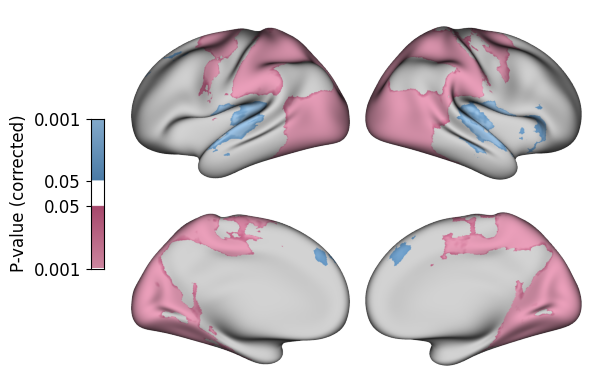

In [12]:
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import numpy as np

# Arial (Helvetica alternative) for all matplotlib text
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial', 'Liberation Sans', 'DejaVu Sans']

# Start virtual display
display = Display(visible=0, size=(1024, 768))
display.start()

# Load searchlight results
glm_dir = "/gpfs/milgram/scratch60/turk-browne/or62/sandbox/searchlight_rsa_results"
category = "contrasts"
fn_av = f"{glm_dir}/{category}/auditory-visual/randomise_output_{category}_auditory-visual_MNI152NLin2009cAsym_tfce_corrp_tstat1.nii.gz"
fn_va = f"{glm_dir}/{category}/visual-auditory/randomise_output_{category}_visual-auditory_MNI152NLin2009cAsym_tfce_corrp_tstat1.nii.gz"
nii_av = nib.load(fn_av)
nii_va = nib.load(fn_va)

# Convert (1-p) -> p
nii_av_p = image.math_img('1 - X', X=nii_av)
nii_va_p = image.math_img('1 - X', X=nii_va)

# Thresholds
p_threshold = 0.05   # display threshold
p_max       = 0.001  # most significant (cap)

# To fslr
fslr_av = transforms.mni152_to_fslr(nii_av_p, '164k')
fslr_va = transforms.mni152_to_fslr(nii_va_p, '164k')
fslr_lh_av = fslr_av[0].darrays[0].data.copy()
fslr_rh_av = fslr_av[1].darrays[0].data.copy()
fslr_lh_va = fslr_va[0].darrays[0].data.copy()
fslr_rh_va = fslr_va[1].darrays[0].data.copy()

# Threshold + cap
for arr in (fslr_lh_av, fslr_rh_av, fslr_lh_va, fslr_rh_va):
    arr[arr > p_threshold] = np.nan
    arr[arr < p_max]       = p_max

# Medial wall
surfaces = fetch_fslr(density='164k')
medial_mask_lh = nib.load(surfaces['medial'][0]).agg_data()
medial_mask_rh = nib.load(surfaces['medial'][1]).agg_data()
fslr_lh_av[medial_mask_lh == 0] = np.nan
fslr_rh_av[medial_mask_rh == 0] = np.nan
fslr_lh_va[medial_mask_lh == 0] = np.nan
fslr_rh_va[medial_mask_rh == 0] = np.nan

# Log space (auditory>visual positive/blue; visual>auditory negative/rose)
fslr_lh_av_log = -np.log10(fslr_lh_av)
fslr_rh_av_log = -np.log10(fslr_rh_av)
fslr_lh_va_log =  np.log10(fslr_lh_va)
fslr_rh_va_log =  np.log10(fslr_rh_va)

# Combine
fslr_lh_data = np.where(~np.isnan(fslr_lh_av_log), fslr_lh_av_log, fslr_lh_va_log)
fslr_rh_data = np.where(~np.isnan(fslr_rh_av_log), fslr_rh_av_log, fslr_rh_va_log)

# Log thresholds
log_max       = -np.log10(p_max)        # ~3
log_threshold = -np.log10(p_threshold)  # ~1.30

# NaN out the sub-threshold band
fslr_lh_data[(fslr_lh_data > -log_threshold) & (fslr_lh_data < log_threshold)] = np.nan
fslr_rh_data[(fslr_rh_data > -log_threshold) & (fslr_rh_data < log_threshold)] = np.nan

# --- Brain colormap: dark = 0.05, bright = 0.001 (TRUE threshold, no gap_scale) ---
pos_neg_threshold = (log_max - log_threshold) / (2 * log_max)
pos_pos_threshold = (log_max + log_threshold) / (2 * log_max)
dark_rose   = (0.65, 0.28, 0.42)   # at 0.05
bright_rose = (0.80, 0.52, 0.62)   # at 0.001
dark_blue   = (0.29, 0.48, 0.65)   # at 0.05
bright_blue = (0.52, 0.67, 0.80)   # at 0.001
cdict = {
    'red':   [(0.0, bright_rose[0], bright_rose[0]),
              (pos_neg_threshold, dark_rose[0], 1.0),
              (pos_pos_threshold, 1.0, dark_blue[0]),
              (1.0, bright_blue[0], bright_blue[0])],
    'green': [(0.0, bright_rose[1], bright_rose[1]),
              (pos_neg_threshold, dark_rose[1], 1.0),
              (pos_pos_threshold, 1.0, dark_blue[1]),
              (1.0, bright_blue[1], bright_blue[1])],
    'blue':  [(0.0, bright_rose[2], bright_rose[2]),
              (pos_neg_threshold, dark_rose[2], 1.0),
              (pos_pos_threshold, 1.0, dark_blue[2]),
              (1.0, bright_blue[2], bright_blue[2])]
}
cmap_custom = LinearSegmentedColormap('custom_diverging', cdict)

# Plot brain WITHOUT surfplot's automatic colorbar
lh, rh = surfaces['inflated']
p = Plot(surf_lh=lh, surf_rh=rh, brightness=0.6)
p.add_layer({'left': fslr_lh_data, 'right': fslr_rh_data},
            cmap=cmap_custom,
            color_range=(-log_max, log_max),
            cbar=False)
fig = p.build()

# --- Custom compact colorbar: VERTICAL, on the LEFT of the brain ---
ncol = 512
gap = 0.17               # cosmetic white-divider width (fraction of bar)
seg = (1.0 - gap) / 2.0
Ln = int(seg * ncol); Gn = int(gap * ncol); Rn = ncol - Ln - Gn
def _grad(c0, c1, n):
    return np.stack([np.linspace(c0[k], c1[k], n) for k in range(3)], axis=1)
bar = np.ones((ncol, 1, 3))
bar[:Ln, 0]      = _grad(bright_rose, dark_rose, Ln)   # bottom: 0.001 -> 0.05 (rose)
bar[Ln:Ln+Gn, 0] = 1.0                                 # white divider
bar[Ln+Gn:, 0]   = _grad(dark_blue, bright_blue, Rn)   # top: 0.05 -> 0.001 (blue)
cax = fig.add_axes([0.07, 0.35, 0.022, 0.30])          # [left, bottom, w, h] - tweak
cax.imshow(bar, origin='lower', aspect='auto', extent=[0, 1, 0, 1])
cax.set_xticks([])
cax.set_yticks([0, seg, seg + gap, 1.0])
cax.set_yticklabels(['0.001', '0.05', '0.05', '0.001'], fontsize=12)
cax.yaxis.set_ticks_position('left')
cax.yaxis.set_label_position('left')
cax.set_ylabel('P-value (corrected)', fontsize=12)

fig.savefig('searchlight_contrasts_unisensory.svg', bbox_inches='tight')
display.stop()

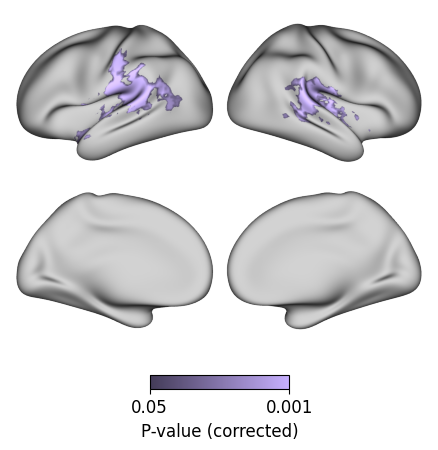

In [8]:
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import numpy as np
import nibabel as nib
from nilearn import image
from neuromaps import transforms
from surfplot import Plot
from pyvirtualdisplay import Display

# Start virtual display
display = Display(visible=0, size=(1024, 768))
display.start()

# Load MNI-158 results
glm_dir = "/gpfs/milgram/scratch60/turk-browne/or62/sandbox/searchlight_rsa_results"
category = "contrasts"

# Load both contrasts needed for conjunction
condition_cong_audio = "congruent-auditory"  # Adjust these names to match your actual files
condition_cong_visual = "congruent-visual"

# Load corrected p-values (stored as 1-p in FSL) for both contrasts
fn_cong_audio = f"{glm_dir}/{category}/{condition_cong_audio}/randomise_output_{category}_{condition_cong_audio}_MNI152NLin2009cAsym_tfce_corrp_tstat1.nii.gz"
fn_cong_visual = f"{glm_dir}/{category}/{condition_cong_visual}/randomise_output_{category}_{condition_cong_visual}_MNI152NLin2009cAsym_tfce_corrp_tstat1.nii.gz"

# Load and convert from (1-p) to p
nii_cong_audio = nib.load(fn_cong_audio)
nii_cong_visual = nib.load(fn_cong_visual)

nii_cong_audio_p = image.math_img('1 - X', X=nii_cong_audio)
nii_cong_visual_p = image.math_img('1 - X', X=nii_cong_visual)

# Conjunction: take the MAXIMUM p-value at each voxel (most conservative)
# This implements the "minimum statistic" conjunction (Nichols et al., 2005)
nii_conjunction_p = image.math_img('np.maximum(img1, img2)', 
                                    img1=nii_cong_audio_p, 
                                    img2=nii_cong_visual_p)

# Define p-value thresholds
p_threshold = 0.05   # minimum p-value to show
p_max = 0.001        # maximum p-value (most significant)

# Transform results to fslr space
fslr = transforms.mni152_to_fslr(nii_conjunction_p, '164k')
fslr_lh, fslr_rh = fslr

# Extract data arrays from GiftiImage objects and threshold them
fslr_lh_data = fslr_lh.darrays[0].data.copy()
fslr_rh_data = fslr_rh.darrays[0].data.copy()

# Set values above threshold to NaN (p > 0.05 = not significant)
fslr_lh_data[fslr_lh_data > p_threshold] = np.nan
fslr_rh_data[fslr_rh_data > p_threshold] = np.nan

# Cap values below max (most significant)
fslr_lh_data[fslr_lh_data < p_max] = p_max
fslr_rh_data[fslr_rh_data < p_max] = p_max

# Add medial wall masking
surfaces = fetch_fslr(density='164k')
medial_mask_lh = nib.load(surfaces['medial'][0]).agg_data()
medial_mask_rh = nib.load(surfaces['medial'][1]).agg_data()
fslr_lh_data[medial_mask_lh == 0] = np.nan
fslr_rh_data[medial_mask_rh == 0] = np.nan

# Transform to log space
fslr_lh_data_log = -np.log10(fslr_lh_data)
fslr_rh_data_log = -np.log10(fslr_rh_data)

# Calculate log thresholds
log_max = -np.log10(p_max)  # ~3
log_threshold = -np.log10(p_threshold)  # ~1.3

# Create sequential colormap: brighter = more significant
# MATCHING GLM conjunction colormap exactly
# #6f638f = (0.435, 0.388, 0.561) exact
# Scale: darker version at threshold, brighter at most sig (keeping exact ratios)
# Ratios: R:G:B = 0.78:0.69:1.0
dark_purple  = (0.26, 0.23, 0.34)   # ~60% of #6f638f — at threshold
light_purple = (0.78, 0.69, 1.0)    # Scaled to blue=1.0 — at most significant

cdict = {
    'red':   [(0.0, dark_purple[0], dark_purple[0]),
              (1.0, light_purple[0], light_purple[0])],
    'green': [(0.0, dark_purple[1], dark_purple[1]),
              (1.0, light_purple[1], light_purple[1])],
    'blue':  [(0.0, dark_purple[2], dark_purple[2]),
              (1.0, light_purple[2], light_purple[2])]
}
cmap_custom = LinearSegmentedColormap('sequential_purple', cdict)

# Colorbar settings
kws = {'location': 'bottom',
       'label_direction': 0,
       'fontsize': 12, 
       'aspect': 10,
       'draw_border': True}

# Plotting with custom purple colormap
lh, rh = surfaces['inflated']
p = Plot(surf_lh=lh, surf_rh=rh, brightness=0.6)
p.add_layer({'left': fslr_lh_data_log, 'right': fslr_rh_data_log}, 
            cmap=cmap_custom,
            color_range=(log_threshold, log_max))

fig = p.build(cbar_kws=kws)

# Add label and set ticks
for ax in fig.axes:
    if hasattr(ax, 'get_xlabel'):
        ax.set_xlabel('P-value (corrected)', fontsize=12)
        ax.set_xticks([log_threshold, log_max])
        ax.set_xticklabels(['0.05', '0.001'])

fig.savefig('rsa_conjunction_congruent_gt_audio_AND_visual.svg', bbox_inches='tight')

# Stop virtual display when done
display.stop()

findfont: Font family ['Helvetica'] not found. Falling back to DejaVu Sans.


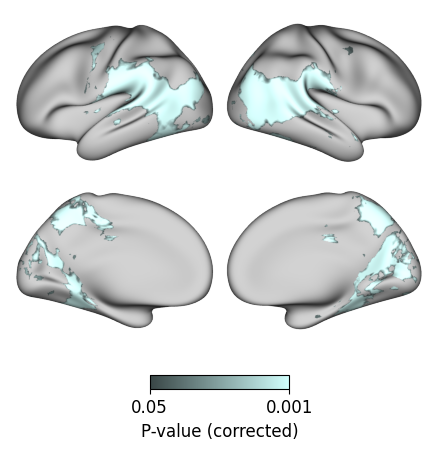

In [9]:
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap, LogNorm
import numpy as np
# Set Helvetica as the default font
plt.rcParams['font.family'] = 'Helvetica'
plt.rcParams['font.sans-serif'] = ['Helvetica']
# Start virtual display
display = Display(visible=0, size=(1024, 768))
display.start()
# Load MNI-158 results
glm_dir = "/gpfs/milgram/scratch60/turk-browne/or62/sandbox/searchlight_rsa_results"
category = "condition"
condition = "cross_visual_auditory"
# Load corrected p-values (stored as 1-p in FSL)
fn = f"{glm_dir}/{condition}/MNI152NLin2009cAsym/randomise_output_{category}_{condition}_MNI152NLin2009cAsym_tfce_corrp_tstat1.nii.gz"
# Load and convert from (1-p) to p
nii = nib.load(fn)
nii = image.math_img('1 - X', X=nii)  # Convert to regular p-values
# Define p-value thresholds
p_threshold = 0.05   # minimum p-value to show
p_max = 0.001        # maximum p-value (most significant)
# Transform results to fslr space
fslr = transforms.mni152_to_fslr(nii, '164k')
fslr_lh, fslr_rh = fslr
# Extract data arrays from GiftiImage objects and threshold them
fslr_lh_data = fslr_lh.darrays[0].data.copy()
fslr_rh_data = fslr_rh.darrays[0].data.copy()
# Set values above threshold to NaN (p > 0.05 = not significant)
fslr_lh_data[fslr_lh_data > p_threshold] = np.nan
fslr_rh_data[fslr_rh_data > p_threshold] = np.nan
# Cap values below max (most significant)
fslr_lh_data[fslr_lh_data < p_max] = p_max
fslr_rh_data[fslr_rh_data < p_max] = p_max
# Add medial wall masking
surfaces = fetch_fslr(density='164k')
medial_mask_lh = nib.load(surfaces['medial'][0]).agg_data()
medial_mask_rh = nib.load(surfaces['medial'][1]).agg_data()
fslr_lh_data[medial_mask_lh == 0] = np.nan
fslr_rh_data[medial_mask_rh == 0] = np.nan
# Transform data to log scale for proper spacing
fslr_lh_data_log = -np.log10(fslr_lh_data)
fslr_rh_data_log = -np.log10(fslr_rh_data)
# Calculate log thresholds
log_max = -np.log10(p_max)  # ~3
log_threshold = -np.log10(p_threshold)  # ~1.3

# TEAL colormap matching #6f638f purple scaling approach
# #8caba9 = (0.549, 0.671, 0.663) — green dominant
# Ratios: R:G:B = 0.82:1.0:0.99 (normalized to green)
#
# Purple approach: ~60% at threshold, dominant channel to 1.0 at most sig
# Purple: dark (0.26, 0.23, 0.34) -> light (0.78, 0.69, 1.0)
dark_teal  = (0.22, 0.27, 0.27)    # ~40% of hex — at threshold (matching purple's ~60% scaling)
light_teal = (0.82, 1.0, 0.99)     # Green at 1.0, others scaled — at most significant

cdict = {
    'red':   [(0.0, dark_teal[0], dark_teal[0]),
              (1.0, light_teal[0], light_teal[0])],
    'green': [(0.0, dark_teal[1], dark_teal[1]),
              (1.0, light_teal[1], light_teal[1])],
    'blue':  [(0.0, dark_teal[2], dark_teal[2]),
              (1.0, light_teal[2], light_teal[2])]
}
cmap_custom = LinearSegmentedColormap('sequential_teal', cdict)
# Colorbar settings
kws = {'location': 'bottom',
       'label_direction': 0,
       'fontsize': 12, 
       'aspect': 10,
       'draw_border': True}
# Plotting with custom colormap
lh, rh = surfaces['inflated']
p = Plot(surf_lh=lh, surf_rh=rh, brightness=0.6)
p.add_layer({'left': fslr_lh_data_log, 'right': fslr_rh_data_log}, 
            cmap=cmap_custom,
            color_range=(log_threshold, log_max))
fig = p.build(cbar_kws=kws)
# Add label and set ticks
for ax in fig.axes:
    if hasattr(ax, 'get_xlabel'):
        ax.set_xlabel('P-value (corrected)', fontsize=12, family='Helvetica')
        ax.set_xticks([log_threshold, log_max])
        ax.set_xticklabels(['0.05', '0.001'])
        # Ensure tick labels use Helvetica
        for label in ax.get_xticklabels():
            label.set_family('Helvetica')
fig.savefig('transfer.svg', bbox_inches='tight')
# Stop virtual display when done
display.stop()

In [12]:
res = build_resources(nib.load(path_contrasts("congruent-auditory", "tfce_corrp_tstat1")))
ld = nib.load
p = 0.05
rsa_conj = image.math_img("np.minimum(a,b)",
                          a=ld(path_contrasts("congruent-auditory","tstat1")),
                          b=ld(path_contrasts("congruent-visual","tstat1")))
rsa_blocks = [
    (r"Auditory $>$ visual",
     clusters_only(ld(path_contrasts("auditory-visual","tstat1")),
                   [ld(path_contrasts("auditory-visual","tfce_corrp_tstat1"))], p, res)),
    (r"Visual $>$ auditory",
     clusters_only(ld(path_contrasts("visual-auditory","tstat1")),
                   [ld(path_contrasts("visual-auditory","tfce_corrp_tstat1"))], p, res)),
    (r"Multisensory facilitation (congruent $>$ auditory $\cap$ congruent $>$ visual)",
     clusters_only(rsa_conj,
                   [ld(path_contrasts("congruent-auditory","tfce_corrp_tstat1")),
                    ld(path_contrasts("congruent-visual","tfce_corrp_tstat1"))], p, res)),
    (r"Crossmodal transfer",
     clusters_only(ld(path_condition("cross_visual_auditory","tstat1")),
                   [ld(path_condition("cross_visual_auditory","tfce_corrp_tstat1"))], p, res)),
    (r"Unisensory $>$ incongruent)",
     clusters_only(ld(path_contrasts("unisensory_mean-incongruent_mean","tstat1")),
                   [ld(path_contrasts("unisensory_mean-incongruent_mean","tfce_corrp_tstat1"))], p, res)),
]
supertable(rsa_blocks, p,
           "Whole-brain searchlight (RSA) cluster peaks.",
           "table:rsa-clusters-p05", "rsa_clusters_p05.tex",
           short="Whole-brain searchlight cluster peaks",
           extra=r"The multisensory facilitation conjunction requires both contrasts to survive; its peak "
                 r"statistic is the minimum of the two contrast $t$-maps. The unisensory $>$ incongruent contrast "
                 r"compares the mean of the auditory and visual conditions against the mean of the auditory and "
                 r"visual components of incongruent audiovisual pairs. Superior temporal sulcus (STS) effects "
                 r"appear under adjacent superior/middle temporal gyrus and planum temporale labels, as the "
                 r"Harvard-Oxford atlas does not delineate the sulcus.")

In [13]:
res = build_resources(nib.load(path_contrasts("congruent-auditory", "tfce_corrp_tstat1")))
ld = nib.load
p = 0.001

rsa_conj = image.math_img("np.minimum(a,b)",
                          a=ld(path_contrasts("congruent-auditory","tstat1")),
                          b=ld(path_contrasts("congruent-visual","tstat1")))

rsa_blocks = [
    (r"Auditory $>$ visual",
     clusters_only(ld(path_contrasts("auditory-visual","tstat1")),
                   [ld(path_contrasts("auditory-visual","tfce_corrp_tstat1"))], p, res)),
    (r"Visual $>$ auditory",
     clusters_only(ld(path_contrasts("visual-auditory","tstat1")),
                   [ld(path_contrasts("visual-auditory","tfce_corrp_tstat1"))], p, res)),
    (r"Multisensory facilitation (congruent $>$ auditory $\cap$ congruent $>$ visual)",
     clusters_only(rsa_conj,
                   [ld(path_contrasts("congruent-auditory","tfce_corrp_tstat1")),
                    ld(path_contrasts("congruent-visual","tfce_corrp_tstat1"))], p, res)),
    (r"Crossmodal transfer",
     clusters_only(ld(path_condition("cross_visual_auditory","tstat1")),
                   [ld(path_condition("cross_visual_auditory","tfce_corrp_tstat1"))], p, res)),
    (r"Unisensory $>$ incongruent)",
     clusters_only(ld(path_contrasts("unisensory_mean-incongruent_mean","tstat1")),
                   [ld(path_contrasts("unisensory_mean-incongruent_mean","tfce_corrp_tstat1"))], p, res)),
]

supertable(rsa_blocks, p,
           "Whole-brain searchlight (RSA) cluster peaks.",
           "table:rsa-clusters-p001", "rsa_clusters_p001.tex",
           short="Whole-brain searchlight cluster peaks",
           extra=r"The multisensory facilitation conjunction requires both contrasts to survive; its peak "
                 r"statistic is the minimum of the two contrast $t$-maps. Superior temporal sulcus (STS) effects "
                 r"appear under adjacent superior/middle temporal gyrus and planum temporale labels, as the "
                 r"Harvard-Oxford atlas does not delineate the sulcus.")

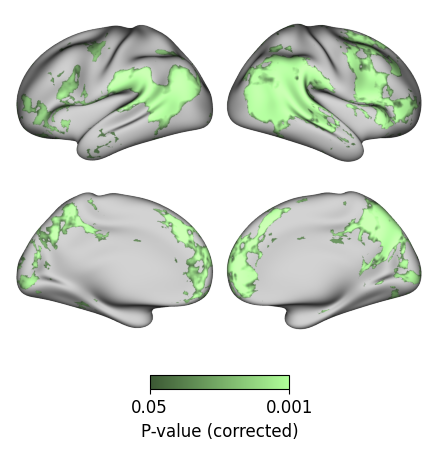

In [10]:
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap, LogNorm
import numpy as np
# Set Helvetica as the default font
plt.rcParams['font.family'] = 'Helvetica'
plt.rcParams['font.sans-serif'] = ['Helvetica']
# Start virtual display
display = Display(visible=0, size=(1024, 768))
display.start()
# Load MNI-158 results
glm_dir = "/gpfs/milgram/scratch60/turk-browne/or62/sandbox/searchlight_rsa_results"
category = "contrasts"
condition = "unisensory_mean-incongruent_mean"
# Load corrected p-values (stored as 1-p in FSL)
fn = f"{glm_dir}/{category}/{condition}/randomise_output_{category}_{condition}_MNI152NLin2009cAsym_tfce_corrp_tstat1.nii.gz"
# Load and convert from (1-p) to p
nii = nib.load(fn)
nii = image.math_img('1 - X', X=nii)  # Convert to regular p-values
# Define p-value thresholds
p_threshold = 0.05   # minimum p-value to show
p_max = 0.001        # maximum p-value (most significant)
# Transform results to fslr space
fslr = transforms.mni152_to_fslr(nii, '164k')
fslr_lh, fslr_rh = fslr
# Extract data arrays from GiftiImage objects and threshold them
fslr_lh_data = fslr_lh.darrays[0].data.copy()
fslr_rh_data = fslr_rh.darrays[0].data.copy()
# Set values above threshold to NaN (p > 0.05 = not significant)
fslr_lh_data[fslr_lh_data > p_threshold] = np.nan
fslr_rh_data[fslr_rh_data > p_threshold] = np.nan
# Cap values below max (most significant)
fslr_lh_data[fslr_lh_data < p_max] = p_max
fslr_rh_data[fslr_rh_data < p_max] = p_max
# Add medial wall masking
surfaces = fetch_fslr(density='164k')
medial_mask_lh = nib.load(surfaces['medial'][0]).agg_data()
medial_mask_rh = nib.load(surfaces['medial'][1]).agg_data()
fslr_lh_data[medial_mask_lh == 0] = np.nan
fslr_rh_data[medial_mask_rh == 0] = np.nan
# Transform data to log scale for proper spacing
fslr_lh_data_log = -np.log10(fslr_lh_data)
fslr_rh_data_log = -np.log10(fslr_rh_data)
# Calculate log thresholds
log_max = -np.log10(p_max)  # ~3
log_threshold = -np.log10(p_threshold)  # ~1.3

# GREEN colormap matching #6f638f purple scaling approach
# Purple: dark (0.26, 0.23, 0.34) -> light (0.78, 0.69, 1.0)
# Purple ratios: R:G:B = 0.78:0.69:1.0 (blue dominant)
# 
# For green, use same approach with green dominant
# Green ratios: R:G:B = 0.78:1.0:0.69 (green dominant, same relative ratios)
dark_green  = (0.23, 0.34, 0.20)    # ~60% — at threshold (matching purple's ~60%)
light_green = (0.69, 1.0, 0.60)     # Scaled to green=1.0 — at most significant

cdict = {
    'red':   [(0.0, dark_green[0], dark_green[0]),
              (1.0, light_green[0], light_green[0])],
    'green': [(0.0, dark_green[1], dark_green[1]),
              (1.0, light_green[1], light_green[1])],
    'blue':  [(0.0, dark_green[2], dark_green[2]),
              (1.0, light_green[2], light_green[2])]
}
cmap_custom = LinearSegmentedColormap('sequential_green', cdict)
# Colorbar settings
kws = {'location': 'bottom',
       'label_direction': 0,
       'fontsize': 12, 
       'aspect': 10,
       'draw_border': True}
# Plotting with custom colormap
lh, rh = surfaces['inflated']
p = Plot(surf_lh=lh, surf_rh=rh, brightness=0.6)
p.add_layer({'left': fslr_lh_data_log, 'right': fslr_rh_data_log}, 
            cmap=cmap_custom,
            color_range=(log_threshold, log_max))
fig = p.build(cbar_kws=kws)
# Add label and set ticks
for ax in fig.axes:
    if hasattr(ax, 'get_xlabel'):
        ax.set_xlabel('P-value (corrected)', fontsize=12, family='Helvetica')
        ax.set_xticks([log_threshold, log_max])
        ax.set_xticklabels(['0.05', '0.001'])
        # Ensure tick labels use Helvetica
        for label in ax.get_xticklabels():
            label.set_family('Helvetica')
fig.savefig('incongruency.svg', bbox_inches='tight')
# Stop virtual display when done
display.stop()

In [18]:
ti = nib.load(path_contrasts("unisensory_mean-incongruent_mean", "tstat1"))
ci = nib.load(path_contrasts("unisensory_mean-incongruent_mean", "tfce_corrp_tstat1"))

cluster_supp(ti, [ci], res, "clusters_rsa_unisensory_gt_incongruent",
             r"Whole-brain searchlight: greater movie-specific pattern similarity for unisensory than incongruent stimuli.",
             "table:rsa-unisensory-gt-incong", "the searchlight $t$-statistic")


### clusters_rsa_unisensory_gt_incongruent_p0p05
Cluster                              Region Hemi  X   Y  Z  Peak t Size (mm3)
      1 Superior temporal gyrus (posterior)    R 65 -33 14   10.54     330533
     1a Lateral occipital cortex (inferior)    R 53 -62  8    9.15           
     1b                    Planum temporale    R 55 -36 19    8.77           
     1c                       Angular gyrus    R 61 -49 15    8.61           

### clusters_rsa_unisensory_gt_incongruent_p0p001
Cluster                              Region Hemi   X   Y   Z  Peak t Size (mm3)
      1 Superior temporal gyrus (posterior)    R  65 -33  14   10.54      71395
     1a Lateral occipital cortex (inferior)    R  53 -62   8    9.15           
     1b                    Planum temporale    R  55 -36  19    8.77           
     1c                       Angular gyrus    R  61 -49  15    8.61           
      2           Parietal operculum cortex    L -50 -35  27    7.62      18222
     2a                    Pl

[(0.05,
    Cluster                               Region Hemi   X   Y   Z  Peak t  \
  0       1  Superior temporal gyrus (posterior)    R  65 -33  14   10.54   
  1      1a  Lateral occipital cortex (inferior)    R  53 -62   8    9.15   
  2      1b                     Planum temporale    R  55 -36  19    8.77   
  3      1c                        Angular gyrus    R  61 -49  15    8.61   
  
    Size (mm3)  
  0     330533  
  1             
  2             
  3             ),
 (0.001,
     Cluster                               Region Hemi   X   Y   Z  Peak t  \
  0        1  Superior temporal gyrus (posterior)    R  65 -33  14   10.54   
  1       1a  Lateral occipital cortex (inferior)    R  53 -62   8    9.15   
  2       1b                     Planum temporale    R  55 -36  19    8.77   
  3       1c                        Angular gyrus    R  61 -49  15    8.61   
  4        2            Parietal operculum cortex    L -50 -35  27    7.62   
  5       2a                     Planum 

import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import numpy as np
import nibabel as nib
from nilearn import image
from neuromaps import transforms
from surfplot import Plot
from pyvirtualdisplay import Display

# Start virtual display
display = Display(visible=0, size=(1024, 768))
display.start()

# Load MNI-158 results
glm_dir = "/gpfs/milgram/scratch60/turk-browne/or62/sandbox/searchlight_rsa_results"
category = "contrasts"

# Load both contrasts needed for conjunction
condition_cong_audio = "congruent-auditory"  # Adjust these names to match your actual files
condition_cong_visual = "congruent-visual"

# Load corrected p-values (stored as 1-p in FSL) for both contrasts
fn_cong_audio = f"{glm_dir}/{category}/{condition_cong_audio}/randomise_output_{category}_{condition_cong_audio}_MNI152NLin2009cAsym_tfce_corrp_tstat1.nii.gz"
fn_cong_visual = f"{glm_dir}/{category}/{condition_cong_visual}/randomise_output_{category}_{condition_cong_visual}_MNI152NLin2009cAsym_tfce_corrp_tstat1.nii.gz"

# Load and convert from (1-p) to p
nii_cong_audio = nib.load(fn_cong_audio)
nii_cong_visual = nib.load(fn_cong_visual)

nii_cong_audio_p = image.math_img('1 - X', X=nii_cong_audio)
nii_cong_visual_p = image.math_img('1 - X', X=nii_cong_visual)

# Conjunction: take the MAXIMUM p-value at each voxel (most conservative)
# This implements the "minimum statistic" conjunction (Nichols et al., 2005)
nii_conjunction_p = image.math_img('np.maximum(img1, img2)', 
                                    img1=nii_cong_audio_p, 
                                    img2=nii_cong_visual_p)

# Define p-value thresholds
p_threshold = 0.05   # minimum p-value to show
p_max = 0.001        # maximum p-value (most significant)

# Transform results to fslr space
fslr = transforms.mni152_to_fslr(nii_conjunction_p, '164k')
fslr_lh, fslr_rh = fslr

# Extract data arrays from GiftiImage objects and threshold them
fslr_lh_data = fslr_lh.darrays[0].data.copy()
fslr_rh_data = fslr_rh.darrays[0].data.copy()

# Set values above threshold to NaN (p > 0.05 = not significant)
fslr_lh_data[fslr_lh_data > p_threshold] = np.nan
fslr_rh_data[fslr_rh_data > p_threshold] = np.nan

# Cap values below max (most significant)
fslr_lh_data[fslr_lh_data < p_max] = p_max
fslr_rh_data[fslr_rh_data < p_max] = p_max

# Add medial wall masking
surfaces = fetch_fslr(density='164k')
medial_mask_lh = nib.load(surfaces['medial'][0]).agg_data()
medial_mask_rh = nib.load(surfaces['medial'][1]).agg_data()
fslr_lh_data[medial_mask_lh == 0] = np.nan
fslr_rh_data[medial_mask_rh == 0] = np.nan

# Transform to log space
fslr_lh_data_log = -np.log10(fslr_lh_data)
fslr_rh_data_log = -np.log10(fslr_rh_data)

# Calculate log thresholds
log_max = -np.log10(p_max)  # ~3
log_threshold = -np.log10(p_threshold)  # ~1.3

# Create sequential colormap: brighter = more significant
# MATCHING GLM conjunction colormap exactly
light_purple = (0.92, 0.75, 1.0)    # Very bright lavender — at most significant
dark_purple  = (0.35, 0.10, 0.55)   # Deep saturated purple — at threshold
cdict = {
    'red':   [(0.0, dark_purple[0], dark_purple[0]),
              (1.0, light_purple[0], light_purple[0])],
    'green': [(0.0, dark_purple[1], dark_purple[1]),
              (1.0, light_purple[1], light_purple[1])],
    'blue':  [(0.0, dark_purple[2], dark_purple[2]),
              (1.0, light_purple[2], light_purple[2])]
}
cmap_custom = LinearSegmentedColormap('sequential_purple', cdict)

# Colorbar settings
kws = {'location': 'bottom',
       'label_direction': 0,
       'fontsize': 12, 
       'aspect': 10,
       'draw_border': True}

# Plotting with custom purple colormap
lh, rh = surfaces['inflated']
p = Plot(surf_lh=lh, surf_rh=rh, brightness=0.6)
p.add_layer({'left': fslr_lh_data_log, 'right': fslr_rh_data_log}, 
            cmap=cmap_custom,
            color_range=(log_threshold, log_max))

fig = p.build(cbar_kws=kws)

# Add label and set ticks
for ax in fig.axes:
    if hasattr(ax, 'get_xlabel'):
        ax.set_xlabel('P-value (corrected)', fontsize=12)
        ax.set_xticks([log_threshold, log_max])
        ax.set_xticklabels(['0.05', '0.001'])

fig.savefig('rsa_conjunction_congruent_gt_audio_AND_visual.svg', bbox_inches='tight')

# Stop virtual display when done
display.stop()

findfont: Font family ['Helvetica'] not found. Falling back to DejaVu Sans.


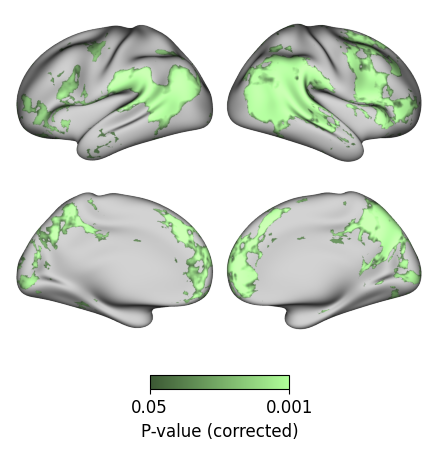

In [8]:
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap, LogNorm
import numpy as np
# Set Helvetica as the default font
plt.rcParams['font.family'] = 'Helvetica'
plt.rcParams['font.sans-serif'] = ['Helvetica']
# Start virtual display
display = Display(visible=0, size=(1024, 768))
display.start()
# Load MNI-158 results
glm_dir = "/gpfs/milgram/scratch60/turk-browne/or62/sandbox/searchlight_rsa_results"
category = "contrasts"
condition = "unisensory_mean-incongruent_mean"
# Load corrected p-values (stored as 1-p in FSL)
fn = f"{glm_dir}/{category}/{condition}/randomise_output_{category}_{condition}_MNI152NLin2009cAsym_tfce_corrp_tstat1.nii.gz"
# Load and convert from (1-p) to p
nii = nib.load(fn)
nii = image.math_img('1 - X', X=nii)  # Convert to regular p-values
# Define p-value thresholds
p_threshold = 0.05   # minimum p-value to show
p_max = 0.001        # maximum p-value (most significant)
# Transform results to fslr space
fslr = transforms.mni152_to_fslr(nii, '164k')
fslr_lh, fslr_rh = fslr
# Extract data arrays from GiftiImage objects and threshold them
fslr_lh_data = fslr_lh.darrays[0].data.copy()
fslr_rh_data = fslr_rh.darrays[0].data.copy()
# Set values above threshold to NaN (p > 0.05 = not significant)
fslr_lh_data[fslr_lh_data > p_threshold] = np.nan
fslr_rh_data[fslr_rh_data > p_threshold] = np.nan
# Cap values below max (most significant)
fslr_lh_data[fslr_lh_data < p_max] = p_max
fslr_rh_data[fslr_rh_data < p_max] = p_max
# Add medial wall masking
surfaces = fetch_fslr(density='164k')
medial_mask_lh = nib.load(surfaces['medial'][0]).agg_data()
medial_mask_rh = nib.load(surfaces['medial'][1]).agg_data()
fslr_lh_data[medial_mask_lh == 0] = np.nan
fslr_rh_data[medial_mask_rh == 0] = np.nan
# Transform data to log scale for proper spacing
fslr_lh_data_log = -np.log10(fslr_lh_data)
fslr_rh_data_log = -np.log10(fslr_rh_data)
# Calculate log thresholds
log_max = -np.log10(p_max)  # ~3
log_threshold = -np.log10(p_threshold)  # ~1.3

# GREEN colormap matching #6f638f purple scaling approach
# Purple: dark (0.26, 0.23, 0.34) -> light (0.78, 0.69, 1.0)
# Purple ratios: R:G:B = 0.78:0.69:1.0 (blue dominant)
# 
# For green, use same approach with green dominant
# Green ratios: R:G:B = 0.78:1.0:0.69 (green dominant, same relative ratios)
dark_green  = (0.23, 0.34, 0.20)    # ~60% — at threshold (matching purple's ~60%)
light_green = (0.69, 1.0, 0.60)     # Scaled to green=1.0 — at most significant

cdict = {
    'red':   [(0.0, dark_green[0], dark_green[0]),
              (1.0, light_green[0], light_green[0])],
    'green': [(0.0, dark_green[1], dark_green[1]),
              (1.0, light_green[1], light_green[1])],
    'blue':  [(0.0, dark_green[2], dark_green[2]),
              (1.0, light_green[2], light_green[2])]
}
cmap_custom = LinearSegmentedColormap('sequential_green', cdict)
# Colorbar settings
kws = {'location': 'bottom',
       'label_direction': 0,
       'fontsize': 12, 
       'aspect': 10,
       'draw_border': True}
# Plotting with custom colormap
lh, rh = surfaces['inflated']
p = Plot(surf_lh=lh, surf_rh=rh, brightness=0.6)
p.add_layer({'left': fslr_lh_data_log, 'right': fslr_rh_data_log}, 
            cmap=cmap_custom,
            color_range=(log_threshold, log_max))
fig = p.build(cbar_kws=kws)
# Add label and set ticks
for ax in fig.axes:
    if hasattr(ax, 'get_xlabel'):
        ax.set_xlabel('P-value (corrected)', fontsize=12, family='Helvetica')
        ax.set_xticks([log_threshold, log_max])
        ax.set_xticklabels(['0.05', '0.001'])
        # Ensure tick labels use Helvetica
        for label in ax.get_xticklabels():
            label.set_family('Helvetica')
fig.savefig('incongruency.svg', bbox_inches='tight')
# Stop virtual display when done
display.stop()

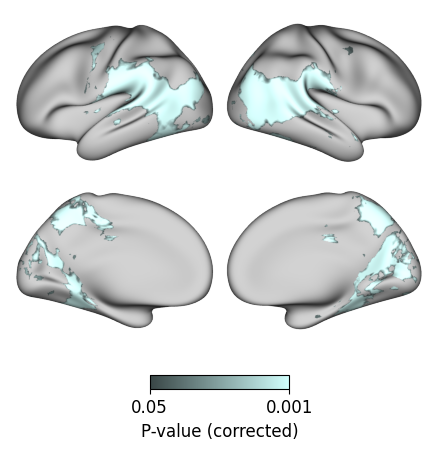

In [10]:
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap, LogNorm
import numpy as np
# Set Helvetica as the default font
plt.rcParams['font.family'] = 'Helvetica'
plt.rcParams['font.sans-serif'] = ['Helvetica']
# Start virtual display
display = Display(visible=0, size=(1024, 768))
display.start()
# Load MNI-158 results
glm_dir = "/gpfs/milgram/scratch60/turk-browne/or62/sandbox/searchlight_rsa_results"
category = "condition"
condition = "cross_visual_auditory"
# Load corrected p-values (stored as 1-p in FSL)
fn = f"{glm_dir}/{condition}/MNI152NLin2009cAsym/randomise_output_{category}_{condition}_MNI152NLin2009cAsym_tfce_corrp_tstat1.nii.gz"
# Load and convert from (1-p) to p
nii = nib.load(fn)
nii = image.math_img('1 - X', X=nii)  # Convert to regular p-values
# Define p-value thresholds
p_threshold = 0.05   # minimum p-value to show
p_max = 0.001        # maximum p-value (most significant)
# Transform results to fslr space
fslr = transforms.mni152_to_fslr(nii, '164k')
fslr_lh, fslr_rh = fslr
# Extract data arrays from GiftiImage objects and threshold them
fslr_lh_data = fslr_lh.darrays[0].data.copy()
fslr_rh_data = fslr_rh.darrays[0].data.copy()
# Set values above threshold to NaN (p > 0.05 = not significant)
fslr_lh_data[fslr_lh_data > p_threshold] = np.nan
fslr_rh_data[fslr_rh_data > p_threshold] = np.nan
# Cap values below max (most significant)
fslr_lh_data[fslr_lh_data < p_max] = p_max
fslr_rh_data[fslr_rh_data < p_max] = p_max
# Add medial wall masking
surfaces = fetch_fslr(density='164k')
medial_mask_lh = nib.load(surfaces['medial'][0]).agg_data()
medial_mask_rh = nib.load(surfaces['medial'][1]).agg_data()
fslr_lh_data[medial_mask_lh == 0] = np.nan
fslr_rh_data[medial_mask_rh == 0] = np.nan
# Transform data to log scale for proper spacing
fslr_lh_data_log = -np.log10(fslr_lh_data)
fslr_rh_data_log = -np.log10(fslr_rh_data)
# Calculate log thresholds
log_max = -np.log10(p_max)  # ~3
log_threshold = -np.log10(p_threshold)  # ~1.3

# TEAL colormap matching #6f638f purple scaling approach
# #8caba9 = (0.549, 0.671, 0.663) — green dominant
# Ratios: R:G:B = 0.82:1.0:0.99 (normalized to green)
#
# Purple approach: ~60% at threshold, dominant channel to 1.0 at most sig
# Purple: dark (0.26, 0.23, 0.34) -> light (0.78, 0.69, 1.0)
dark_teal  = (0.22, 0.27, 0.27)    # ~40% of hex — at threshold (matching purple's ~60% scaling)
light_teal = (0.82, 1.0, 0.99)     # Green at 1.0, others scaled — at most significant

cdict = {
    'red':   [(0.0, dark_teal[0], dark_teal[0]),
              (1.0, light_teal[0], light_teal[0])],
    'green': [(0.0, dark_teal[1], dark_teal[1]),
              (1.0, light_teal[1], light_teal[1])],
    'blue':  [(0.0, dark_teal[2], dark_teal[2]),
              (1.0, light_teal[2], light_teal[2])]
}
cmap_custom = LinearSegmentedColormap('sequential_teal', cdict)
# Colorbar settings
kws = {'location': 'bottom',
       'label_direction': 0,
       'fontsize': 12, 
       'aspect': 10,
       'draw_border': True}
# Plotting with custom colormap
lh, rh = surfaces['inflated']
p = Plot(surf_lh=lh, surf_rh=rh, brightness=0.6)
p.add_layer({'left': fslr_lh_data_log, 'right': fslr_rh_data_log}, 
            cmap=cmap_custom,
            color_range=(log_threshold, log_max))
fig = p.build(cbar_kws=kws)
# Add label and set ticks
for ax in fig.axes:
    if hasattr(ax, 'get_xlabel'):
        ax.set_xlabel('P-value (corrected)', fontsize=12, family='Helvetica')
        ax.set_xticks([log_threshold, log_max])
        ax.set_xticklabels(['0.05', '0.001'])
        # Ensure tick labels use Helvetica
        for label in ax.get_xticklabels():
            label.set_family('Helvetica')
fig.savefig('transfer.svg', bbox_inches='tight')
# Stop virtual display when done
display.stop()

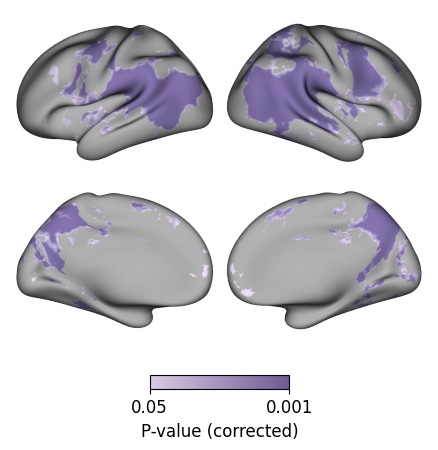

In [7]:
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap, LogNorm
import numpy as np

# Start virtual display
display = Display(visible=0, size=(1024, 768))
display.start()

# Load MNI-158 results
glm_dir = "/gpfs/milgram/scratch60/turk-browne/or62/sandbox/searchlight_rsa_results/"
contrast1 = "visual"  
contrast2 = "auditory"

# Load both contrast results
fn1 = f"{glm_dir}/{contrast1}/MNI152NLin2009cAsym/randomise_output_condition_{contrast1}_MNI152NLin2009cAsym_tfce_corrp_tstat1.nii.gz"
fn2 = f"{glm_dir}/{contrast2}/MNI152NLin2009cAsym/randomise_output_condition_{contrast2}_MNI152NLin2009cAsym_tfce_corrp_tstat1.nii.gz"

nii1 = nib.load(fn1)
nii2 = nib.load(fn2)

# Convert from (1-p) to p for both
nii1_p = image.math_img('1 - X', X=nii1)
nii2_p = image.math_img('1 - X', X=nii2)

# Create strict conjunction: both must be significant at p < 0.05
# Take the maximum (worst) p-value where both are significant
p_threshold_conj = 0.05
conjunction = image.math_img(
    'np.where((X < 0.05) & (Y < 0.05), np.maximum(X, Y), 1)', 
    X=nii1_p, Y=nii2_p
)

# Define p-value thresholds
p_threshold = 0.05   # minimum p-value to show
p_max = 0.001        # maximum p-value (most significant)

# Transform results to fslr space
fslr = transforms.mni152_to_fslr(conjunction, '164k')
fslr_lh, fslr_rh = fslr

# Extract data arrays from GiftiImage objects and threshold them
fslr_lh_data = fslr_lh.darrays[0].data.copy()
fslr_rh_data = fslr_rh.darrays[0].data.copy()

# Set values above threshold to NaN (p > 0.05 = not significant)
fslr_lh_data[fslr_lh_data > p_threshold] = np.nan
fslr_rh_data[fslr_rh_data > p_threshold] = np.nan

# Cap values below max (most significant)
fslr_lh_data[fslr_lh_data < p_max] = p_max
fslr_rh_data[fslr_rh_data < p_max] = p_max

# Add medial wall masking
surfaces = fetch_fslr(density='164k')
medial_mask_lh = nib.load(surfaces['medial'][0]).agg_data()
medial_mask_rh = nib.load(surfaces['medial'][1]).agg_data()
fslr_lh_data[medial_mask_lh == 0] = np.nan
fslr_rh_data[medial_mask_rh == 0] = np.nan

# Transform data to log scale for proper spacing
fslr_lh_data_log = -np.log10(fslr_lh_data)
fslr_rh_data_log = -np.log10(fslr_rh_data)

# Calculate log thresholds
log_max = -np.log10(p_max)  # ~3
log_threshold = -np.log10(p_threshold)  # ~1.3

# Create sequential colormap from light to dark purple
# Light purple to dark purple (#6b5b95)
light_purple = (0.85, 0.80, 0.90)  # Very light purple
dark_purple = (0.42, 0.36, 0.58)   # #6b5b95
cdict = {
    'red':   [(0.0, light_purple[0], light_purple[0]),
              (1.0, dark_purple[0], dark_purple[0])],
    'green': [(0.0, light_purple[1], light_purple[1]),
              (1.0, dark_purple[1], dark_purple[1])],
    'blue':  [(0.0, light_purple[2], light_purple[2]),
              (1.0, dark_purple[2], dark_purple[2])]
}
cmap_custom = LinearSegmentedColormap('sequential_purple', cdict)

# Colorbar settings
kws = {'location': 'bottom',
       'label_direction': 0,
       'fontsize': 12, 
       'aspect': 10,
       'draw_border': True}

# Plotting
lh, rh = surfaces['inflated']
p = Plot(surf_lh=lh, surf_rh=rh)

p.add_layer({'left': fslr_lh_data_log, 'right': fslr_rh_data_log}, 
            cmap=cmap_custom,
            color_range=(log_threshold, log_max))

fig = p.build(cbar_kws=kws)

# Add label and set ticks
for ax in fig.axes:
    if hasattr(ax, 'get_xlabel'):
        ax.set_xlabel('P-value (corrected)', fontsize=12)
        ax.set_xticks([log_threshold, log_max])
        ax.set_xticklabels(['0.05', '0.001'])

fig.savefig('unisensory_both.svg', dpi=300, bbox_inches='tight')

# Stop virtual display when done
display.stop()

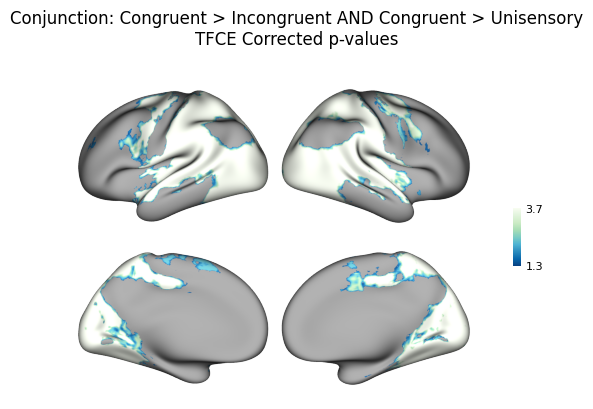

In [ ]:
# Start virtual display
display = Display(visible=0, size=(1024, 768))
display.start()

# Load MNI-158 results
glm_dir = "/gpfs/milgram/scratch60/turk-browne/or62/sandbox/searchlight_rsa_results/contrasts"
contrast1 = "congruent-incongruent_mean"  
contrast2 = "congruent-unisensory_mean"

# Load both contrast results
fn1 = f"{glm_dir}/{contrast1}/randomise_output_contrasts_{contrast1}_MNI152NLin2009cAsym_tfce_corrp_tstat1.nii.gz"
fn2 = f"{glm_dir}/{contrast2}/randomise_output_contrasts_{contrast2}_MNI152NLin2009cAsym_tfce_corrp_tstat1.nii.gz"

nii1 = nib.load(fn1)
nii2 = nib.load(fn2)

# Create strict conjunction: both must be significant at p < 0.05
p_threshold = 0.001
thresh_value = 1 - p_threshold  # 0.95

conjunction = image.math_img(
    'np.where((X > 0.95) & (Y > 0.95), np.minimum(X, Y), 0)', 
    X=nii1, Y=nii2
)

# Transform to -log10(1-p) format
conjunction = image.math_img('-np.log10(1-X)', X=conjunction)

# Define p-value thresholds and their -log10 equivalents
p_threshold_viz = 0.05  # minimum p-value to show
p_max = 0.00001         # maximum p-value (most significant)
log_threshold = -np.log10(p_threshold_viz)  # ~1.3
log_max = -np.log10(p_max)                  # ~3.0

# Transform results to fslr space
fslr = transforms.mni152_to_fslr(conjunction, '164k')
fslr_lh, fslr_rh = fslr

# Extract data arrays from GiftiImage objects and threshold them
fslr_lh_data = fslr_lh.darrays[0].data.copy()
fslr_rh_data = fslr_rh.darrays[0].data.copy()

# Set values below threshold to NaN (won't be plotted)
fslr_lh_data[fslr_lh_data < log_threshold] = np.nan
fslr_rh_data[fslr_rh_data < log_threshold] = np.nan

# Optionally cap values above max
fslr_lh_data[fslr_lh_data > log_max] = log_max
fslr_rh_data[fslr_rh_data > log_max] = log_max

# Colorbar settings
kws = {'location': 'right', 'label_direction': 45, 'decimals': 1,
       'fontsize': 8, 'n_ticks': 2, 'shrink': .15, 'aspect': 8,
       'draw_border': False}

# Plotting
surfaces = fetch_fslr(density='164k')
lh, rh = surfaces['inflated']
p = Plot(surf_lh=lh, surf_rh=rh)

# Add layer with conjunction data
p.add_layer({'left': fslr_lh_data, 'right': fslr_rh_data}, cmap='GnBu_r')
fig = p.build(cbar_kws=kws)

# Add title
fig.suptitle('Conjunction: Congruent > Incongruent AND Congruent > Unisensory\nTFCE Corrected p-values', 
             fontsize=12, y=0.95)

fig.savefig('conjunction_brain_plot.png', dpi=300, bbox_inches='tight')

# Stop virtual display when done
display.stop()

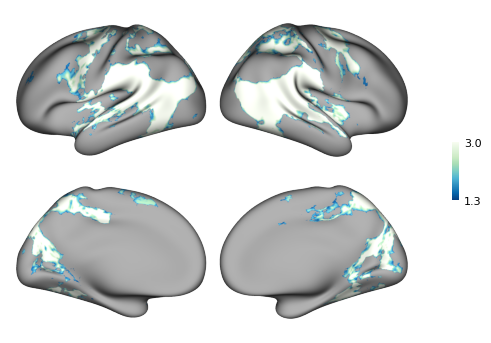

In [4]:
# Start virtual display
display = Display(visible=0, size=(1024, 768))
display.start()

# Load MNI-158 results
glm_dir_base = "/gpfs/milgram/scratch60/turk-browne/or62/sandbox/searchlight_rsa_results"
glm_dir_contrasts = f"{glm_dir_base}/contrasts"

# Define conditions and contrasts as specified
conditions = ["auditory", "visual", "congruent"]
contrasts = ["congruent-unisensory_mean", "unisensory_mean-incongruent_mean"]

# Load all condition results
condition_niis = []
for condition in conditions:
    fn = f"{glm_dir_base}/{condition}/MNI152NLin2009cAsym/randomise_output_condition_{condition}_MNI152NLin2009cAsym_tfce_corrp_tstat1.nii.gz"
    condition_niis.append(nib.load(fn))

# Load contrast results
contrast_niis = []
for contrast in contrasts:
    fn = f"{glm_dir_contrasts}/{contrast}/randomise_output_contrasts_{contrast}_MNI152NLin2009cAsym_tfce_corrp_tstat1.nii.gz"
    contrast_niis.append(nib.load(fn))

# Create conjunction: ALL conditions AND contrasts must be significant
p_threshold = 0.05
thresh_value = 1 - p_threshold  # 0.95

# Build the conjunction for 3 conditions + 2 contrasts = 5 total
conjunction = image.math_img(
    'np.where((A > 0.95) & (B > 0.95) & (C > 0.95) & (D > 0.95) & (E > 0.95), '
    'np.minimum(np.minimum(np.minimum(np.minimum(A, B), C), D), E), 0)',
    A=condition_niis[0],  # auditory
    B=condition_niis[1],  # visual  
    C=condition_niis[2],  # congruent
    D=contrast_niis[0],   # congruent-incongruent_mean
    E=contrast_niis[1]    # unisensory_mean-incongruent_mean
)

# Transform to -log10(1-p) format
conjunction = image.math_img('-np.log10(1-X)', X=conjunction)

# Define p-value thresholds and their -log10 equivalents
p_threshold_viz = 0.05  # minimum p-value to show
p_max = 0.001         # maximum p-value (most significant)
log_threshold = -np.log10(p_threshold_viz)  # ~1.3
log_max = -np.log10(p_max)                  # ~5.0

# Transform results to fslr space
fslr = transforms.mni152_to_fslr(conjunction, '164k')
fslr_lh, fslr_rh = fslr

# Extract data arrays from GiftiImage objects and threshold them
fslr_lh_data = fslr_lh.darrays[0].data.copy()
fslr_rh_data = fslr_rh.darrays[0].data.copy()

# Set values below threshold to NaN (won't be plotted)
fslr_lh_data[fslr_lh_data < log_threshold] = np.nan
fslr_rh_data[fslr_rh_data < log_threshold] = np.nan

# Optionally cap values above max
fslr_lh_data[fslr_lh_data > log_max] = log_max
fslr_rh_data[fslr_rh_data > log_max] = log_max

# **ADD MEDIAL WALL MASKING - MINIMAL ADDITION**
surfaces = fetch_fslr(density='164k')
medial_mask_lh = nib.load(surfaces['medial'][0]).agg_data()
medial_mask_rh = nib.load(surfaces['medial'][1]).agg_data()
fslr_lh_data[medial_mask_lh == 0] = np.nan
fslr_rh_data[medial_mask_rh == 0] = np.nan

# Colorbar settings
kws = {'location': 'right', 'label_direction': 45, 'decimals': 1,
       'fontsize': 8, 'n_ticks': 2, 'shrink': .15, 'aspect': 8,
       'draw_border': False}

# Plotting
lh, rh = surfaces['inflated']
p = Plot(surf_lh=lh, surf_rh=rh)

# Add layer with conjunction data
p.add_layer({'left': fslr_lh_data, 'right': fslr_rh_data}, cmap='GnBu_r')

fig = p.build(cbar_kws=kws)

# Add updated title

fig.savefig('multisensory_conjunction_brain_plot.png', dpi=300, bbox_inches='tight')

# Stop virtual display when done
display.stop()

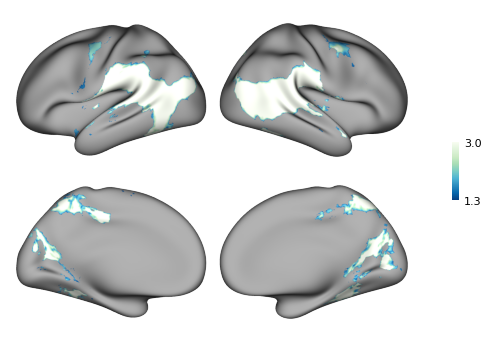

In [7]:
# Start virtual display
display = Display(visible=0, size=(1024, 768))
display.start()

# Load MNI-158 results
glm_dir_base = "/gpfs/milgram/scratch60/turk-browne/or62/sandbox/searchlight_rsa_results"
glm_dir_contrasts = f"{glm_dir_base}/contrasts"

# Define conditions and contrasts as specified
conditions = ["auditory", "visual", "congruent", "cross_visual_auditory"]
contrasts = ["congruent-unisensory_mean", "unisensory_mean-incongruent_mean"]

# Load all condition results
condition_niis = []
for condition in conditions:
    if condition == "cross_visual_auditory":
        fn = f"{glm_dir_base}/{condition}/MNI152NLin2009cAsym/randomise_output_condition_{condition}_MNI152NLin2009cAsym_tfce_corrp_tstat1.nii.gz"
    else:
        fn = f"{glm_dir_base}/{condition}/MNI152NLin2009cAsym/randomise_output_condition_{condition}_MNI152NLin2009cAsym_tfce_corrp_tstat1.nii.gz"
    condition_niis.append(nib.load(fn))

# Load contrast results
contrast_niis = []
for contrast in contrasts:
    fn = f"{glm_dir_contrasts}/{contrast}/randomise_output_contrasts_{contrast}_MNI152NLin2009cAsym_tfce_corrp_tstat1.nii.gz"
    contrast_niis.append(nib.load(fn))

# Create conjunction: ALL conditions AND contrasts must be significant
p_threshold = 0.05
thresh_value = 1 - p_threshold  # 0.95

# Build the conjunction for 4 conditions + 2 contrasts = 6 total
conjunction = image.math_img(
    'np.where((A > 0.95) & (B > 0.95) & (C > 0.95) & (D > 0.95) & (E > 0.95) & (F > 0.95), '
    'np.minimum(np.minimum(np.minimum(np.minimum(np.minimum(A, B), C), D), E), F), 0)',
    A=condition_niis[0],  # auditory
    B=condition_niis[1],  # visual  
    C=condition_niis[2],  # congruent
    D=condition_niis[3],  # cross_visual_auditory
    E=contrast_niis[0],   # congruent-unisensory_mean
    F=contrast_niis[1]    # unisensory_mean-incongruent_mean
)

# Transform to -log10(1-p) format
conjunction = image.math_img('-np.log10(1-X)', X=conjunction)

# Define p-value thresholds and their -log10 equivalents
p_threshold_viz = 0.05  # minimum p-value to show
p_max = 0.001         # maximum p-value (most significant)
log_threshold = -np.log10(p_threshold_viz)  # ~1.3
log_max = -np.log10(p_max)                  # ~3.0

# Transform results to fslr space
fslr = transforms.mni152_to_fslr(conjunction, '164k')
fslr_lh, fslr_rh = fslr

# Extract data arrays from GiftiImage objects and threshold them
fslr_lh_data = fslr_lh.darrays[0].data.copy()
fslr_rh_data = fslr_rh.darrays[0].data.copy()

# Set values below threshold to NaN (won't be plotted)
fslr_lh_data[fslr_lh_data < log_threshold] = np.nan
fslr_rh_data[fslr_rh_data < log_threshold] = np.nan

# Optionally cap values above max
fslr_lh_data[fslr_lh_data > log_max] = log_max
fslr_rh_data[fslr_rh_data > log_max] = log_max

# **ADD MEDIAL WALL MASKING - MINIMAL ADDITION**
surfaces = fetch_fslr(density='164k')
medial_mask_lh = nib.load(surfaces['medial'][0]).agg_data()
medial_mask_rh = nib.load(surfaces['medial'][1]).agg_data()
fslr_lh_data[medial_mask_lh == 0] = np.nan
fslr_rh_data[medial_mask_rh == 0] = np.nan

# Colorbar settings
kws = {'location': 'right', 'label_direction': 45, 'decimals': 1,
       'fontsize': 8, 'n_ticks': 2, 'shrink': .15, 'aspect': 8,
       'draw_border': False}

# Plotting
lh, rh = surfaces['inflated']
p = Plot(surf_lh=lh, surf_rh=rh)

# Add layer with conjunction data
p.add_layer({'left': fslr_lh_data, 'right': fslr_rh_data}, cmap='GnBu_r')

fig = p.build(cbar_kws=kws)

# Add updated title
fig.savefig('multisensory_conjunction_brain_plot.png', dpi=300, bbox_inches='tight')

# Stop virtual display when done
display.stop()